# VisDrone Dataset Visualization

This notebook gives a compact view of split sizes and class balance across the local VisDrone detection dataset.

In [50]:
from pathlib import Path
import logging

import matplotlib.pyplot as plt
import pandas as pd

from src.analysis import (
    build_class_distribution_frame,
    build_split_summary_and_class_counts,
    collect_bbox_metrics,
    collect_bbox_size_data,
    collect_small_images,
    find_out_of_boundaries_images,
    inspect_dataset_issues,
    remove_issue_files,
    summarize_bbox_size_distribution,
)
from src.visualization import visualize_random_samples
from src.visualization_helpers import (
    plot_bbox_distributions,
    plot_class_distribution,
    plot_split_summary,
)

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")


In [51]:
logging.basicConfig(level=logging.INFO, filename="a.log", filemode="a")
logger = logging.getLogger(__name__)

logger.debug("A DEBUG Message")
logger.info("An INFO")
logger.warning("A WARNING")
logger.error("An ERROR")
logger.critical("A message of CRITICAL severity")


In [ ]:
DATA_DIR = Path("./data")

split_dirs, summary_df, class_distributions = build_split_summary_and_class_counts(DATA_DIR)
summary_df


,split,images,label_files,boxes,avg_boxes_per_image,image_share
2,VisDrone2019-DET-train,6471,6471,353550,54.64,0.63
1,VisDrone2019-DET-test-dev,1610,1610,77547,48.17,0.16
0,VisDrone2019-DET-test-challenge,1580,0,0,0.00,0.15
3,VisDrone2019-DET-val,548,548,40169,73.30,0.05


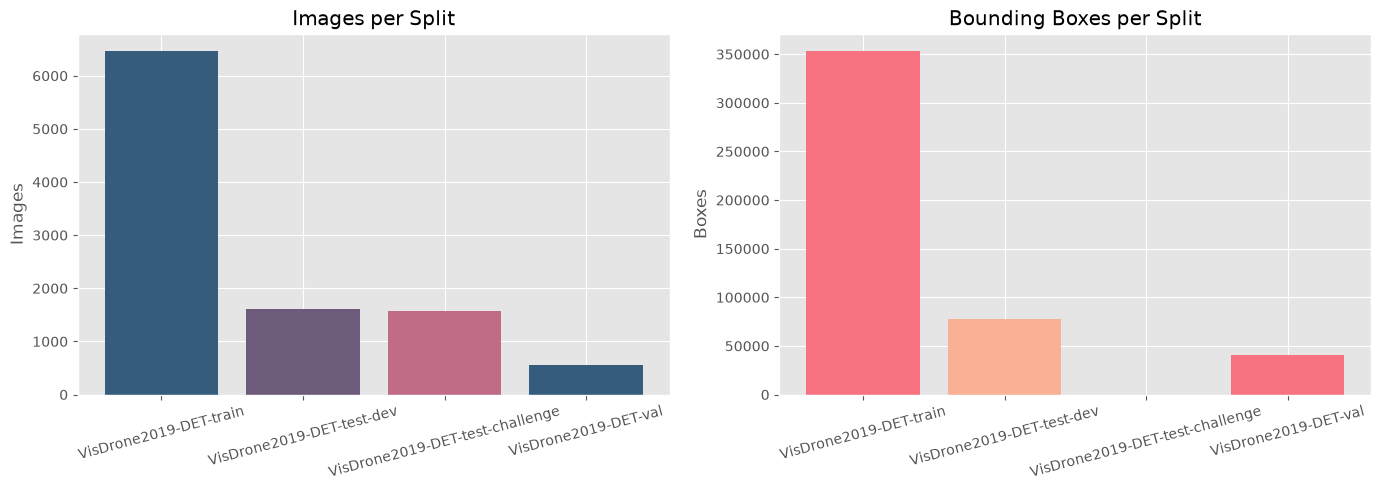

In [53]:
plot_split_summary(summary_df)
plt.show()


In [54]:
class_df = build_class_distribution_frame(class_distributions)
class_df


,VisDrone2019-DET-test-challenge,VisDrone2019-DET-test-dev,VisDrone2019-DET-train,VisDrone2019-DET-val,total
others,0,265,1532,32,1829
awning_tricycle,0,599,3246,532,4377
tricycle,0,530,4812,1045,6387
bus,0,2940,5926,251,9117
ignored_regions,0,2180,8813,1378,12371
bicycle,0,1302,10480,1287,13069
truck,0,2659,12875,750,16284
van,0,5771,24956,1975,32702
people,0,6376,27059,5125,38560
motor,0,5845,29647,4886,40378


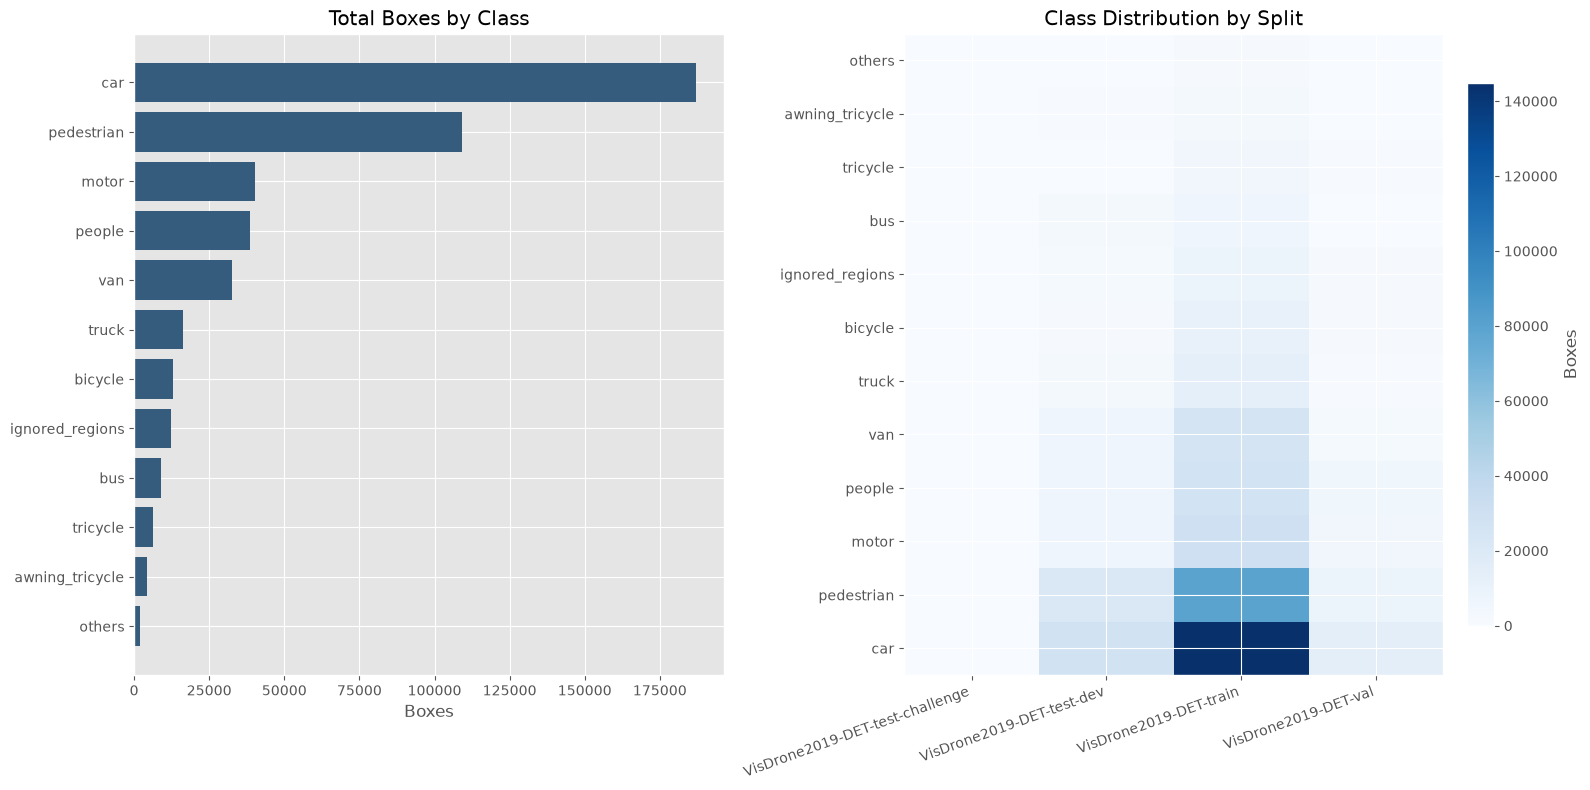

In [55]:
plot_class_distribution(class_df)
plt.show()


In [56]:
bbox_df = collect_bbox_metrics(split_dirs)

bbox_df.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])


,width,height,area,aspect_ratio
count,"471,266.00","471,266.00","471,266.00","471,266.00"
mean,37.19,36.19,"2,286.28",1.09
std,40.18,32.93,"6,342.56",0.70
min,2.00,0.00,0.00,0.00
10%,7.00,10.00,90.00,0.41
25%,13.00,16.00,224.01,0.56
50%,24.00,26.00,637.99,0.89
75%,47.00,44.00,"1,886.01",1.44
90%,82.00,72.00,"5,291.98",2.10
max,"1,424.00",790.00,"355,432.35",31.27


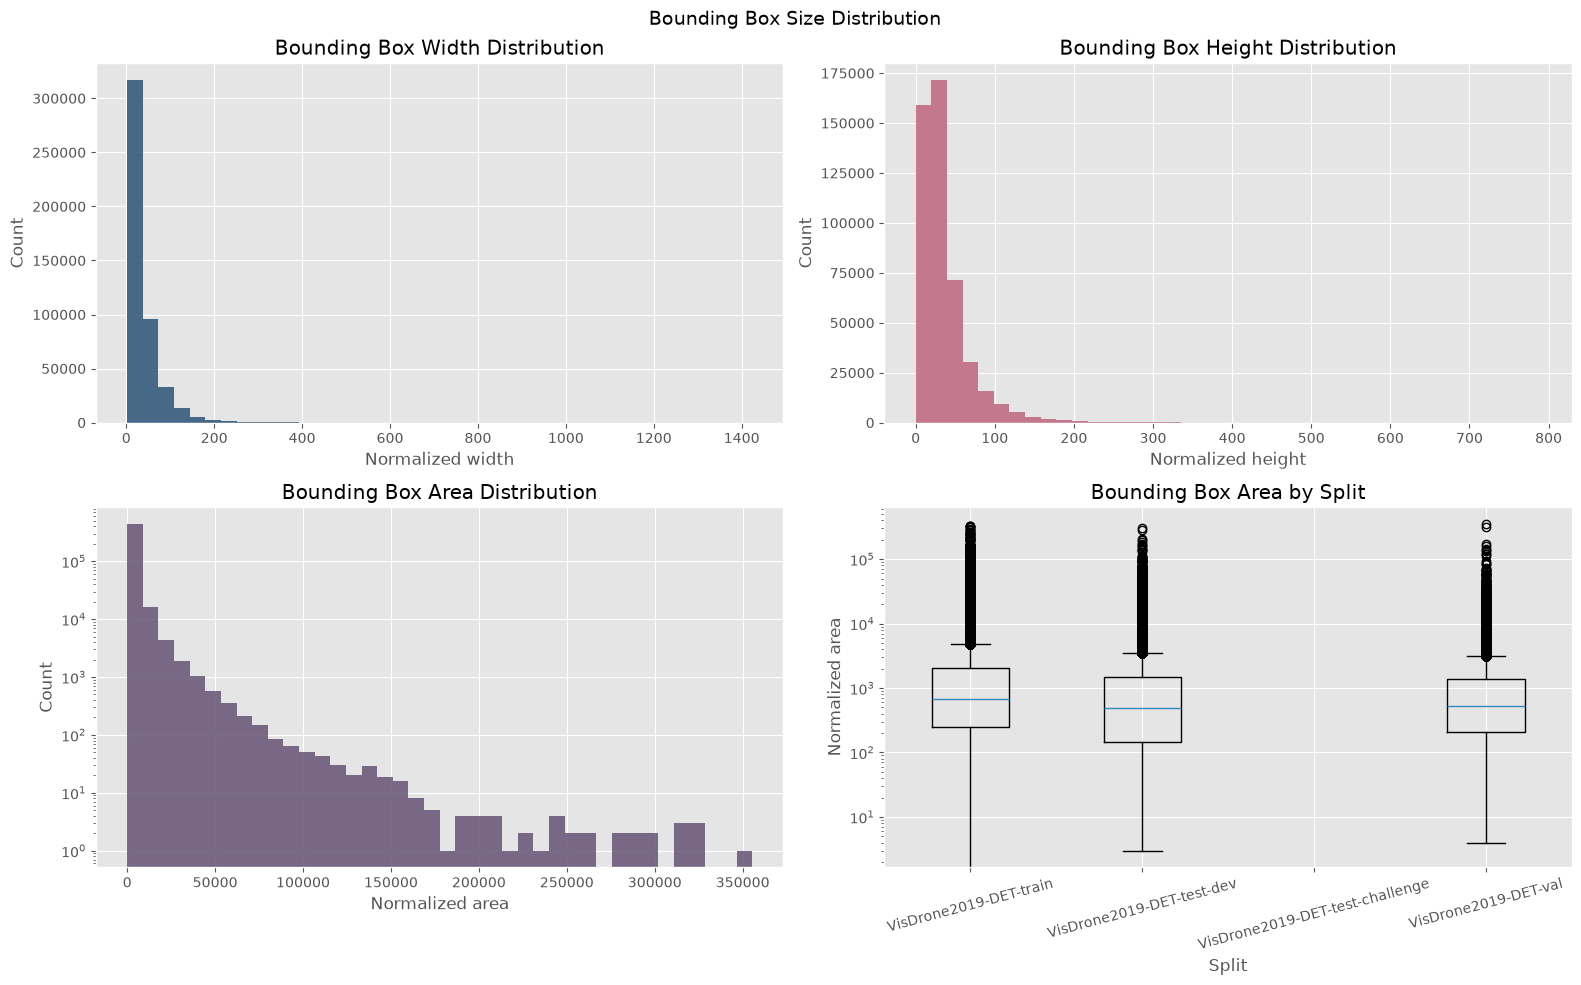

In [57]:
plot_bbox_distributions(bbox_df, summary_df)
plt.show()


In [ ]:
bbox_size_rows, bbox_size_df = collect_bbox_size_data(split_dirs)
size_distribution, size_distribution_by_split = summarize_bbox_size_distribution(bbox_size_df)

print("Overall box size distribution (COCO-style thresholds in pixel area):")
display(size_distribution)
print("\nBox size distribution by split (%):")
size_distribution_by_split


Overall box size distribution (COCO-style thresholds in pixel area):


,percentage
size_bucket,
small,62.00
medium,32.97
large,5.03



Box size distribution by split (%):


size_bucket,small,medium,large
split,,,
VisDrone2019-DET-test-dev,67.38,29.33,3.29
VisDrone2019-DET-train,60.16,34.19,5.64
VisDrone2019-DET-val,67.76,29.25,2.99


In [59]:
inspection_results = inspect_dataset_issues(DATA_DIR)


Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/VisDrone2019-DET-test-dev
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing hashes: 100%|██████████| 1610/1610 [00:03<00:00, 455.89it/s]


Issue checks completed. 0 issues found in the dataset. To see a detailed report of issues found, use imagelab.report().
Issues found in images in order of severity in the dataset

|    | issue_type       |   num_images |
|---:|:-----------------|-------------:|
|  0 | dark             |            0 |
|  1 | light            |            0 |
|  2 | odd_aspect_ratio |            0 |
|  3 | low_information  |            0 |
|  4 | blurry           |            0 |
|  5 | grayscale        |            0 |
|  6 | odd_size         |            0 |
|  7 | exact_duplicates |            0 |
|  8 | near_duplicates  |            0 | 

Reading images from /home/stiro/hobby/CV/Edge-Vehicle-Detection-and-Tracking/data/VisDrone2019-DET-train
Checking for dark, light, odd_aspect_ratio, low_information, exact_duplicates, near_duplicates, blurry, grayscale, odd_size images ...


Computing scores:  22%|██▏       | 1410/6471 [00:14<00:50, 100.49it/s]Process ForkPoolWorker-142:
Process ForkPoolWorker-133:
Process ForkPoolWorker-134:
Process ForkPoolWorker-137:
Process ForkPoolWorker-144:
Traceback (most recent call last):
Process ForkPoolWorker-135:
  File "/home/stiro/anaconda3/envs/image-object-detection/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
  File "/home/stiro/anaconda3/envs/image-object-detection/lib/python3.13/multiprocessing/process.py", line 108, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
Process ForkPoolWorker-139:
Process ForkPoolWorker-140:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/stiro/anaconda3/envs/image-object-detection/lib/python3.13/multiprocessing/process.py", line 313, in _bootstrap
    self.run()
    ~~~~~~~~^^
Traceback (most recent call last):
Tracebac

KeyboardInterrupt: 

In [ ]:
remove_issue_files(inspection_results, logger=logger)


In [ ]:
out_of_boundaries_images = find_out_of_boundaries_images(split_dirs)


In [ ]:
print(out_of_boundaries_images)


[]


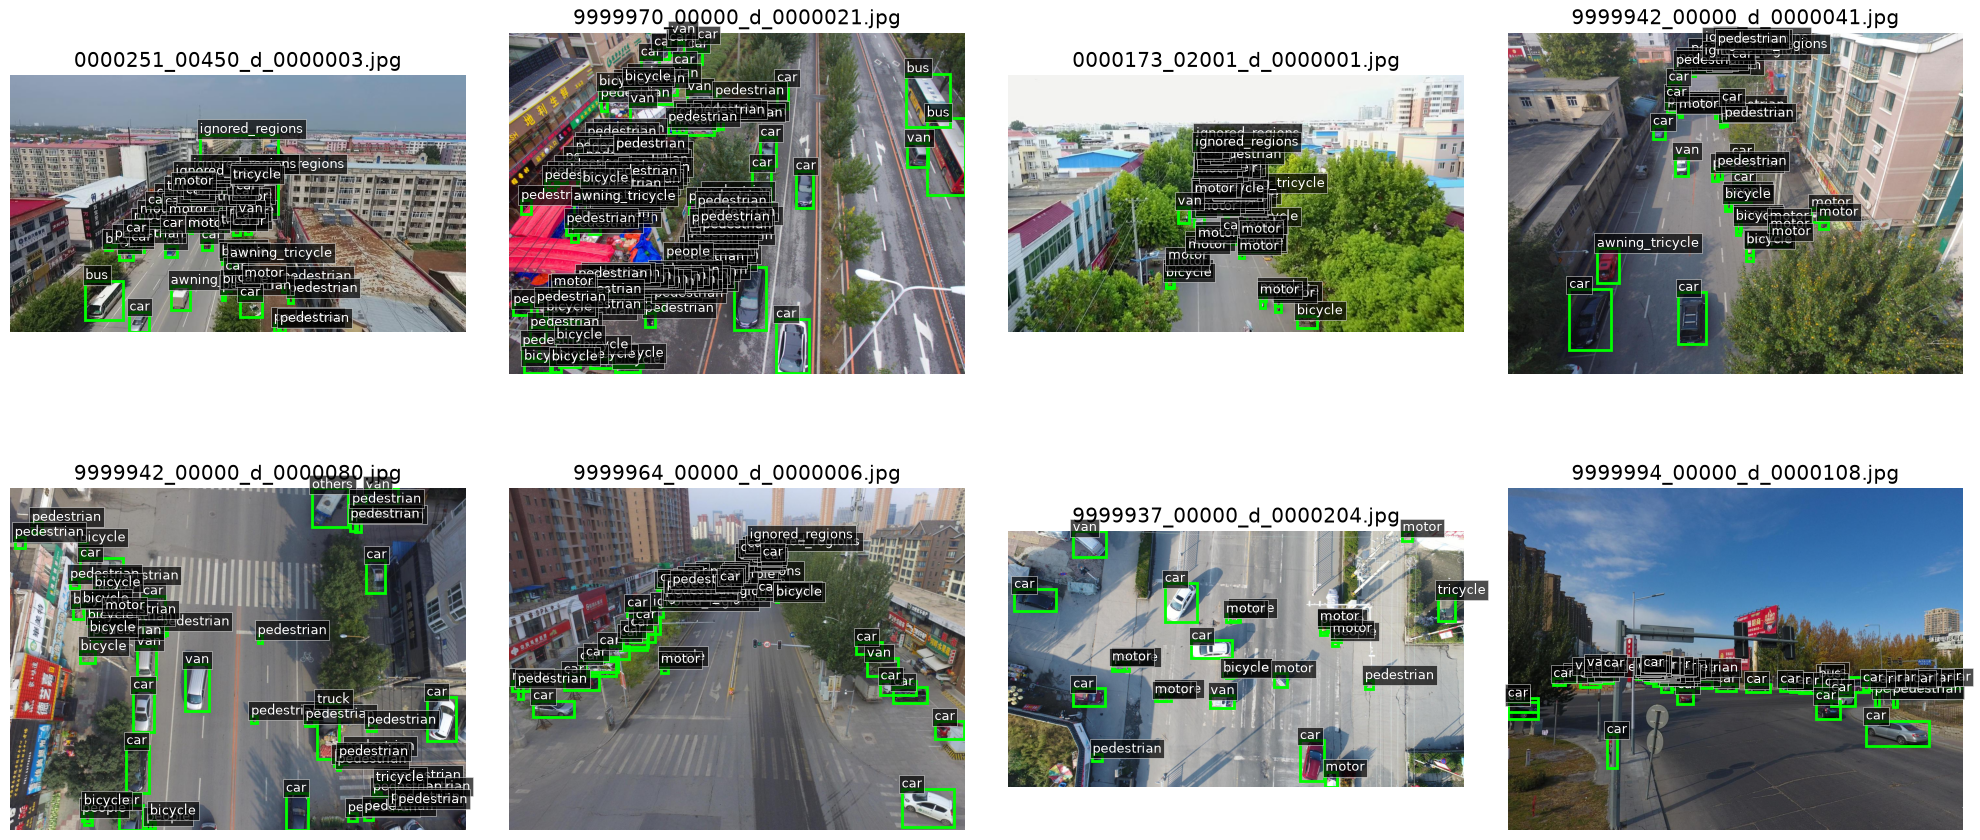

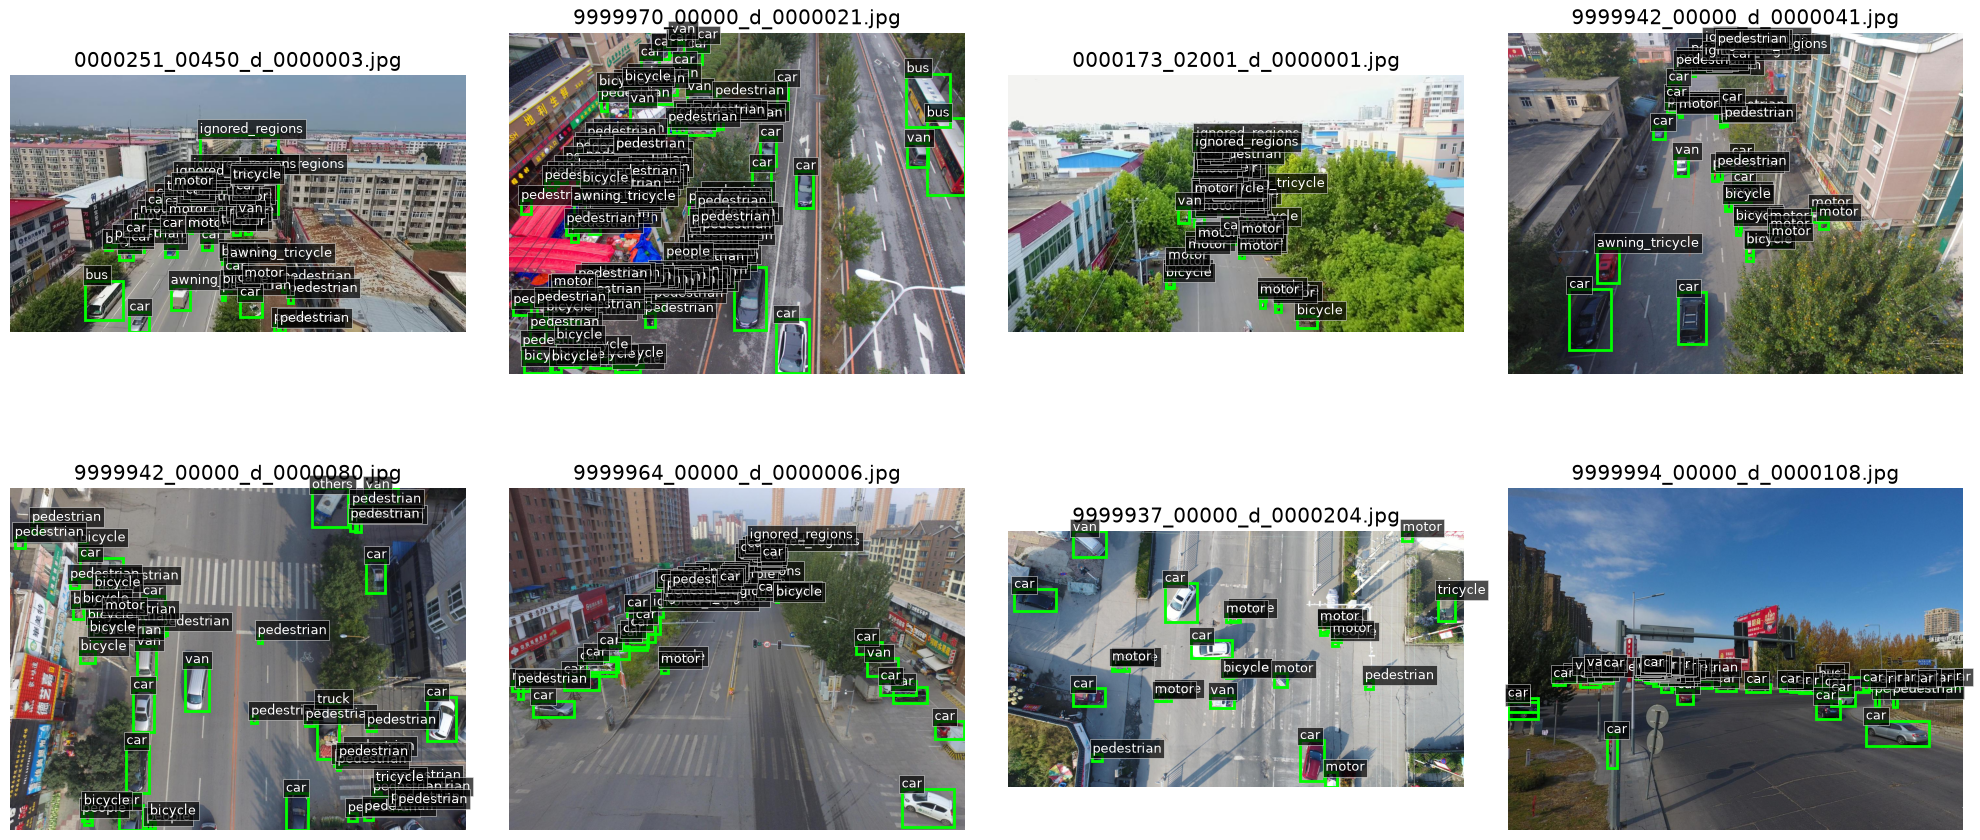

In [60]:
visualize_random_samples(DATA_DIR / "VisDrone2019-DET-train", values=[2])


In [61]:
small_images = collect_small_images(bbox_size_rows, split_name="VisDrone2019-DET-train")
